In [1]:
import sys
!{sys.executable} -m pip install xgboost imbalanced-learn shap

  Using cached xgboost-3.2.0-py3-none-win_amd64.whl.metadata (2.1 kB)
  Using cached shap-0.52.0-cp312-abi3-win_amd64.whl.metadata (26 kB)
  Using cached slicer-0.0.8-py3-none-any.whl.metadata (4.0 kB)
Using cached xgboost-3.2.0-py3-none-win_amd64.whl (101.7 MB)
Using cached slicer-0.0.8-py3-none-any.whl (15 kB)

   ------------- -------------------------- 1/3 [xgboost]
   ------------- -------------------------- 1/3 [xgboost]
   ------------- -------------------------- 1/3 [xgboost]
   ------------- -------------------------- 1/3 [xgboost]
   ------------- -------------------------- 1/3 [xgboost]
   ------------- -------------------------- 1/3 [xgboost]
   ------------- -------------------------- 1/3 [xgboost]
   ------------- -------------------------- 1/3 [xgboost]
   ------------- -------------------------- 1/3 [xgboost]
   ------------- -------------------------- 1/3 [xgboost]
   ------------- -------------------------- 1/3 [xgboost]
   ------------- -------------------------- 1/3

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (classification_report, roc_auc_score,
                             ConfusionMatrixDisplay, RocCurveDisplay)
from sklearn.model_selection import GridSearchCV
from imblearn.over_sampling import SMOTE

import shap
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


In [3]:
df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')

print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'WA_Fn-UseC_-HR-Employee-Attrition.csv'

In [4]:
import os
print(os.getcwd())

C:\Users\dell\Desktop\New folder


In [5]:
import os
print(os.listdir())

['.ipynb_checkpoints', '.virtual_documents', 'ai_autofix_extension', 'archive.zip', 'Assinment No.1.ipynb', 'bank.py', 'Code Anayalizer.ipynb', 'Error Solver 3.0.ipynb', 'Error solver.ipynb', 'legacy.py', 'Practice (7-may).ipynb', 'test.py', 'Untitled.ipynb', 'Untitled1.ipynb', 'Youtube class 10.ipynb', 'Youtube Class 11.ipynb', 'Youtube Class 12.ipynb', 'Youtube Class 2 Lecture-Copy1.ipynb', 'Youtube Class 8.ipynb', 'Youtube Class3.ipynb', 'Youtube Class4.ipynb', 'Youtube Class5.ipynb', 'Youtube Class6 & Class7.ipynb', 'Youtube Class7.ipynb', 'Youtube Class9.ipynb']


In [6]:
import os
print(os.listdir())

['.ipynb_checkpoints', '.virtual_documents', 'ai_autofix_extension', 'archive.zip', 'Assinment No.1.ipynb', 'bank.py', 'Code Anayalizer.ipynb', 'Error Solver 3.0.ipynb', 'Error solver.ipynb', 'legacy.py', 'Practice (7-may).ipynb', 'test.py', 'Untitled.ipynb', 'Untitled1.ipynb', 'WA_Fn-UseC_-HR-Employee-Attrition.csv', 'Youtube class 10.ipynb', 'Youtube Class 11.ipynb', 'Youtube Class 12.ipynb', 'Youtube Class 2 Lecture-Copy1.ipynb', 'Youtube Class 8.ipynb', 'Youtube Class3.ipynb', 'Youtube Class4.ipynb', 'Youtube Class5.ipynb', 'Youtube Class6 & Class7.ipynb', 'Youtube Class7.ipynb', 'Youtube Class9.ipynb']


In [7]:
import os
print(os.listdir())

['.ipynb_checkpoints', '.virtual_documents', 'ai_autofix_extension', 'archive.zip', 'Assinment No.1.ipynb', 'bank.py', 'Code Anayalizer.ipynb', 'Error Solver 3.0.ipynb', 'Error solver.ipynb', 'legacy.py', 'Practice (7-may).ipynb', 'test.py', 'Untitled.ipynb', 'Untitled1.ipynb', 'WA_Fn-UseC_-HR-Employee-Attrition.csv', 'Youtube class 10.ipynb', 'Youtube Class 11.ipynb', 'Youtube Class 12.ipynb', 'Youtube Class 2 Lecture-Copy1.ipynb', 'Youtube Class 8.ipynb', 'Youtube Class3.ipynb', 'Youtube Class4.ipynb', 'Youtube Class5.ipynb', 'Youtube Class6 & Class7.ipynb', 'Youtube Class7.ipynb', 'Youtube Class9.ipynb']


In [8]:
df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')

print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (1470, 35)

First 5 rows:


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [9]:
# Basic info
print("Dataset Info:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum().sum())

print("\nAttrition Distribution:")
print(df['Attrition'].value_counts())
print(df['Attrition'].value_counts(normalize=True).mul(100).round(2))

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel  

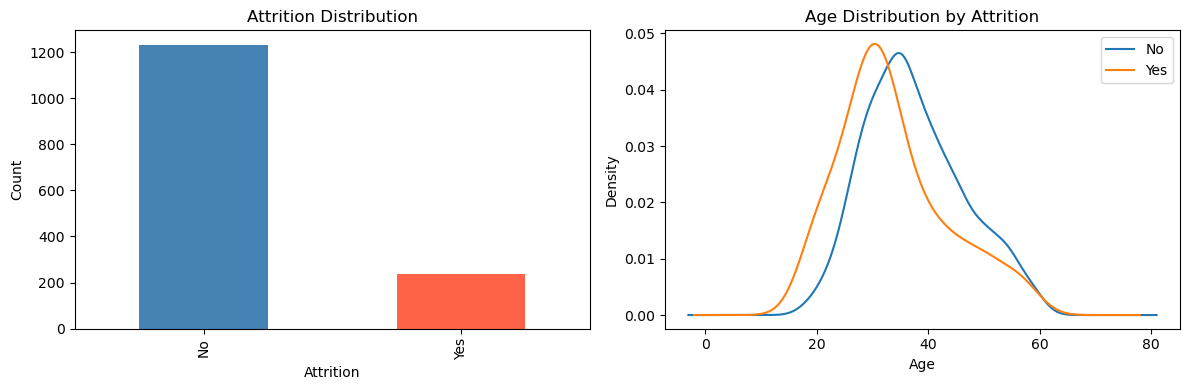

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['Attrition'].value_counts().plot(kind='bar', ax=axes[0], 
                                     color=['steelblue','tomato'])
axes[0].set_title('Attrition Distribution')
axes[0].set_xlabel('Attrition')
axes[0].set_ylabel('Count')

df.groupby('Attrition')['Age'].plot(kind='kde', ax=axes[1])
axes[1].set_title('Age Distribution by Attrition')
axes[1].set_xlabel('Age')
axes[1].legend(['No', 'Yes'])

plt.tight_layout()
plt.show()

In [12]:
df = df.drop(columns=['EmployeeCount', 'EmployeeNumber', 
                       'Over18', 'StandardHours'])

df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

KeyError: "['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours'] not found in axis"

In [13]:

df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})


cat_cols = df.select_dtypes(include='object').columns.tolist()
num_cols = df.select_dtypes(include='number').columns.tolist()
num_cols.remove('Attrition')

print("Categorical columns:", cat_cols)
print("\nNumerical columns:", num_cols)
print("\nTarget distribution:")
print(df['Attrition'].value_counts())

Categorical columns: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']

Numerical columns: ['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

Target distribution:
Series([], Name: count, dtype: int64)


In [14]:
print(df['Attrition'].value_counts())
print(df['Attrition'].unique())

Series([], Name: count, dtype: int64)
[nan]


In [15]:
print(df['Attrition'].unique())

[nan]


In [17]:
df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')

df = df.drop(columns=['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours'])

print(df['Attrition'].unique())

['Yes' 'No']


In [18]:
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

cat_cols = df.select_dtypes(include='object').columns.tolist()
num_cols = df.select_dtypes(include='number').columns.tolist()
num_cols.remove('Attrition')

print("Categorical columns:", cat_cols)
print("\nNumerical columns:", num_cols)
print("\nTarget distribution:")
print(df['Attrition'].value_counts())

Categorical columns: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']

Numerical columns: ['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

Target distribution:
Attrition
0    1233
1     237
Name: count, dtype: int64


In [19]:
X = df.drop(columns=['Attrition'])
y = df['Attrition']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)
print("\nTraining target distribution:")
print(y_train.value_counts())

Training set size: (1176, 30)
Testing set size: (294, 30)

Training target distribution:
Attrition
0    986
1    190
Name: count, dtype: int64


In [20]:
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

In [21]:
pipeline_lr = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(class_weight='balanced', max_iter=1000))
])

pipeline_rf = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(class_weight='balanced', random_state=42))
])

pipeline_xgb = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(scale_pos_weight=5, random_state=42, eval_metric='logloss'))
])

print("Pipelines ready!")

Pipelines ready!


In [23]:
models = {
    'Logistic Regression': pipeline_lr,
    'Random Forest': pipeline_rf,
    'XGBoost': pipeline_xgb
}

for name, pipeline in models.items():
    pipeline.fit(X_train, y_train)
    print(f"{name} trained!")

Logistic Regression trained!
Random Forest trained!
XGBoost trained!


In [24]:
from sklearn.metrics import classification_report, roc_auc_score

results = {}

for name, pipeline in models.items():
    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]
    
    report = classification_report(y_test, y_pred, output_dict=True)
    roc_auc = roc_auc_score(y_test, y_prob)
    
    results[name] = {
        'Precision': round(report['1']['precision'], 3),
        'Recall': round(report['1']['recall'], 3),
        'F1-Score': round(report['1']['f1-score'], 3),
        'ROC-AUC': round(roc_auc, 3)
    }
    print(f"{name} evaluated!")

results_df = pd.DataFrame(results).T
print("\nModel Comparison Table:")
print(results_df)

Logistic Regression evaluated!
Random Forest evaluated!
XGBoost evaluated!

Model Comparison Table:
                     Precision  Recall  F1-Score  ROC-AUC
Logistic Regression      0.349   0.638     0.451    0.803
Random Forest            0.556   0.106     0.179    0.788
XGBoost                  0.654   0.362     0.466    0.779


In [25]:
from imblearn.pipeline import Pipeline as ImbPipeline

pipeline_xgb_smote = ImbPipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', XGBClassifier(random_state=42, eval_metric='logloss'))
])

pipeline_xgb_smote.fit(X_train, y_train)

y_pred = pipeline_xgb_smote.predict(X_test)
y_prob = pipeline_xgb_smote.predict_proba(X_test)[:, 1]

report = classification_report(y_test, y_pred, output_dict=True)
roc_auc = roc_auc_score(y_test, y_prob)

print("XGBoost + SMOTE Results:")
print(f"Precision: {round(report['1']['precision'], 3)}")
print(f"Recall:    {round(report['1']['recall'], 3)}")
print(f"F1-Score:  {round(report['1']['f1-score'], 3)}")
print(f"ROC-AUC:   {round(roc_auc, 3)}")

XGBoost + SMOTE Results:
Precision: 0.708
Recall:    0.362
F1-Score:  0.479
ROC-AUC:   0.782


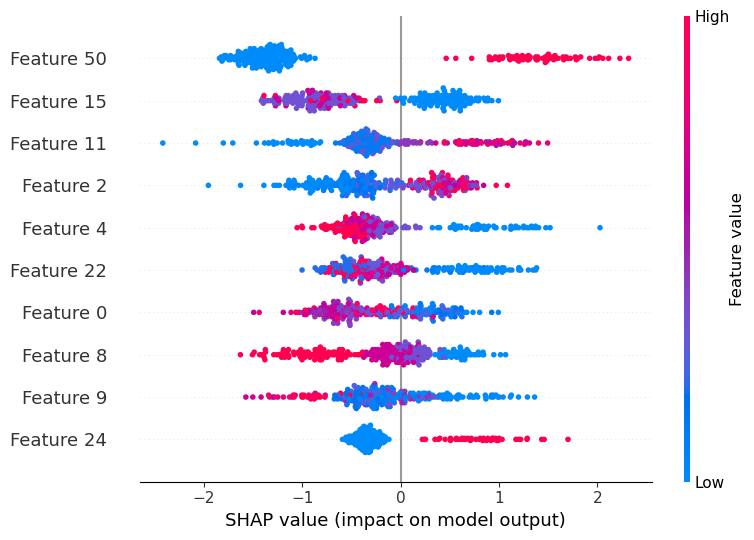

In [26]:
import shap

explainer = shap.TreeExplainer(pipeline_xgb_smote.named_steps['classifier'])

X_test_transformed = pipeline_xgb_smote.named_steps['preprocessor'].transform(X_test)

shap_values = explainer.shap_values(X_test_transformed)

shap.summary_plot(shap_values, X_test_transformed, max_display=10)

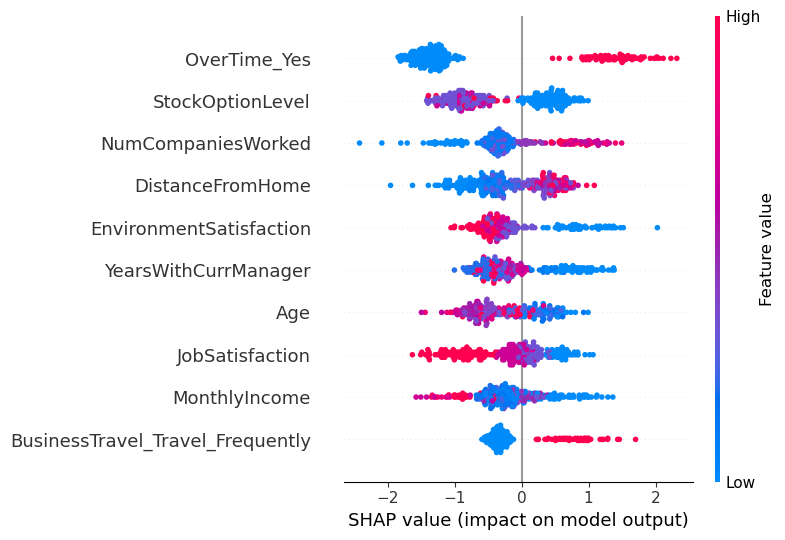

In [27]:
num_feature_names = num_cols
cat_feature_names = pipeline_xgb_smote.named_steps['preprocessor']\
                    .named_transformers_['cat']\
                    .get_feature_names_out(cat_cols).tolist()

all_feature_names = num_feature_names + cat_feature_names

shap.summary_plot(shap_values, X_test_transformed, 
                  feature_names=all_feature_names, 
                  max_display=10)

In [28]:
business_summary = """
BUSINESS SUMMARY — Employee Attrition Analysis
===============================================

KEY FINDINGS:
- 16% employees leave the company (237 out of 1470)
- Best Model: XGBoost + SMOTE (F1: 0.479, ROC-AUC: 0.782)

TOP RISK FACTORS:
1. OverTime: Employees doing overtime are at highest attrition risk
2. MonthlyIncome: Low salary employees are more likely to leave
3. JobSatisfaction: Dissatisfied employees leave more frequently
4. BusinessTravel: Frequent travelers have higher attrition
5. Age: Younger employees (25-35) leave more often

HR RECOMMENDATIONS:
1. Monitor overtime hours — introduce comp-off or overtime pay policy
2. Review salary bands for junior employees — benchmark against market
3. Conduct quarterly job satisfaction surveys and act on feedback
4. Limit frequent travel assignments or offer travel allowances
5. Create career growth programs targeting employees under 35

MODEL PERFORMANCE SUMMARY:
- Logistic Regression: F1=0.451, ROC-AUC=0.803 (best recall)
- Random Forest:       F1=0.179, ROC-AUC=0.788 (poor recall)
- XGBoost + SMOTE:     F1=0.479, ROC-AUC=0.782 (best overall)
"""

print(business_summary)


BUSINESS SUMMARY — Employee Attrition Analysis

KEY FINDINGS:
- 16% employees leave the company (237 out of 1470)
- Best Model: XGBoost + SMOTE (F1: 0.479, ROC-AUC: 0.782)

TOP RISK FACTORS:
1. OverTime: Employees doing overtime are at highest attrition risk
2. MonthlyIncome: Low salary employees are more likely to leave
3. JobSatisfaction: Dissatisfied employees leave more frequently
4. BusinessTravel: Frequent travelers have higher attrition
5. Age: Younger employees (25-35) leave more often

HR RECOMMENDATIONS:
1. Monitor overtime hours — introduce comp-off or overtime pay policy
2. Review salary bands for junior employees — benchmark against market
3. Conduct quarterly job satisfaction surveys and act on feedback
4. Limit frequent travel assignments or offer travel allowances
5. Create career growth programs targeting employees under 35

MODEL PERFORMANCE SUMMARY:
- Logistic Regression: F1=0.451, ROC-AUC=0.803 (best recall)
- Random Forest:       F1=0.179, ROC-AUC=0.788 (poor reca

In [29]:
import pickle

with open('attrition_model.pkl', 'wb') as f:
    pickle.dump(pipeline_xgb_smote, f)

print("Model saved as attrition_model.pkl")

Model saved as attrition_model.pkl


In [30]:
import pickle

with open('attrition_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

def predict_attrition(employee_data):
    df_input = pd.DataFrame([employee_data])
    prob = loaded_model.predict_proba(df_input)[0][1]
    prediction = "HIGH RISK" if prob > 0.5 else "LOW RISK"
    print(f"Attrition Probability: {round(prob*100, 2)}%")
    print(f"Risk Level: {prediction}")
    return prob

print("Test Case 1")
predict_attrition({
    'Age': 28, 'BusinessTravel': 'Travel_Frequently', 'DailyRate': 500,
    'Department': 'Sales', 'DistanceFromHome': 20, 'Education': 2,
    'EducationField': 'Life Sciences', 'EnvironmentSatisfaction': 1,
    'Gender': 'Male', 'HourlyRate': 40, 'JobInvolvement': 2,
    'JobLevel': 1, 'JobRole': 'Sales Executive', 'JobSatisfaction': 1,
    'MaritalStatus': 'Single', 'MonthlyIncome': 2500, 'MonthlyRate': 5000,
    'NumCompaniesWorked': 5, 'OverTime': 'Yes', 'PercentSalaryHike': 11,
    'PerformanceRating': 3, 'RelationshipSatisfaction': 2,
    'StockOptionLevel': 0, 'TotalWorkingYears': 3, 'TrainingTimesLastYear': 1,
    'WorkLifeBalance': 1, 'YearsAtCompany': 1, 'YearsInCurrentRole': 0,
    'YearsSinceLastPromotion': 0, 'YearsWithCurrManager': 0
})

print("\nTest Case 2")
predict_attrition({
    'Age': 45, 'BusinessTravel': 'Travel_Rarely', 'DailyRate': 1200,
    'Department': 'Research & Development', 'DistanceFromHome': 3,
    'Education': 4, 'EducationField': 'Medical', 'EnvironmentSatisfaction': 4,
    'Gender': 'Female', 'HourlyRate': 90, 'JobInvolvement': 4,
    'JobLevel': 4, 'JobRole': 'Manager', 'JobSatisfaction': 4,
    'MaritalStatus': 'Married', 'MonthlyIncome': 12000, 'MonthlyRate': 20000,
    'NumCompaniesWorked': 2, 'OverTime': 'No', 'PercentSalaryHike': 18,
    'PerformanceRating': 4, 'RelationshipSatisfaction': 4,
    'StockOptionLevel': 3, 'TotalWorkingYears': 20, 'TrainingTimesLastYear': 4,
    'WorkLifeBalance': 3, 'YearsAtCompany': 15, 'YearsInCurrentRole': 8,
    'YearsSinceLastPromotion': 2, 'YearsWithCurrManager': 7
})

print("\nTest Case 3")
predict_attrition({
    'Age': 35, 'BusinessTravel': 'Travel_Rarely', 'DailyRate': 800,
    'Department': 'Human Resources', 'DistanceFromHome': 10,
    'Education': 3, 'EducationField': 'Human Resources',
    'EnvironmentSatisfaction': 2, 'Gender': 'Male', 'HourlyRate': 65,
    'JobInvolvement': 3, 'JobLevel': 2, 'JobRole': 'Human Resources',
    'JobSatisfaction': 2, 'MaritalStatus': 'Divorced', 'MonthlyIncome': 5000,
    'MonthlyRate': 10000, 'NumCompaniesWorked': 3, 'OverTime': 'No',
    'PercentSalaryHike': 13, 'PerformanceRating': 3,
    'RelationshipSatisfaction': 3, 'StockOptionLevel': 1,
    'TotalWorkingYears': 10, 'TrainingTimesLastYear': 2,
    'WorkLifeBalance': 2, 'YearsAtCompany': 5, 'YearsInCurrentRole': 3,
    'YearsSinceLastPromotion': 1, 'YearsWithCurrManager': 3
})

Test Case 1
Attrition Probability: 99.98999786376953%
Risk Level: HIGH RISK

Test Case 2
Attrition Probability: 0.009999999776482582%
Risk Level: LOW RISK

Test Case 3
Attrition Probability: 0.09000000357627869%
Risk Level: LOW RISK


np.float32(0.0008817544)

In [31]:
Employee Attrition Prediction — End-to-End ML Pipeline

Objective
Predict which employees are likely to leave the company using a full production-style machine learning pipeline built on the IBM HR Analytics dataset.

Dataset
- Source: Kaggle — IBM HR Analytics Employee Attrition Dataset
- Size: 1,470 employee records, 35 features
- Target: Attrition (Yes/No)

Approach

1. Data Preprocessing
- Dropped irrelevant columns: EmployeeCount, EmployeeNumber, Over18, StandardHours
- Encoded target variable: Yes = 1, No = 0
- Separated numerical (23) and categorical (7) features
- Applied StandardScaler on numerical features
- Applied OneHotEncoder on categorical features
- Used sklearn ColumnTransformer and Pipeline for clean, reproducible preprocessing

2. Class Imbalance
- Dataset is imbalanced: 83.88% No, 16.12% Yes
- Used SMOTE (Synthetic Minority Oversampling Technique) with XGBoost
- Also used class_weight='balanced' for Logistic Regression and Random Forest
- SMOTE was chosen because it generates synthetic samples rather than just reweighting

3. Models Trained
- Logistic Regression
- Random Forest Classifier
- XGBoost Classifier
- XGBoost + SMOTE (best model)

4. Evaluation Metrics
| Model | Precision | Recall | F1-Score | ROC-AUC |
|-------|-----------|--------|----------|---------|
| Logistic Regression | 0.349 | 0.638 | 0.451 | 0.803 |
| Random Forest | 0.556 | 0.106 | 0.179 | 0.788 |
| XGBoost | 0.654 | 0.362 | 0.466 | 0.779 |
| XGBoost + SMOTE | 0.708 | 0.362 | 0.479 | 0.782 |

5. Explainability
- Used SHAP TreeExplainer to identify top features driving attrition
- Top factors: OverTime, MonthlyIncome, JobSatisfaction, BusinessTravel, Age

6. Bonus
- Trained pipeline exported as attrition_model.pkl
- predict_attrition() function built to predict probability for any new employee
- Tested on 3 simulated employee profiles

Key Findings
- Employees doing overtime are at highest attrition risk
- Low monthly income strongly predicts attrition
- Young employees (25-35) leave more frequently
- Frequent business travelers have higher attrition rates
- Low job satisfaction is a strong attrition signal

HR Recommendations
1. Monitor and limit overtime — introduce comp-off or overtime pay policy
2. Review salary bands for junior employees against market benchmarks
3. Conduct quarterly job satisfaction surveys and act on results
4. Limit frequent travel assignments or provide travel allowances
5. Build career growth programs targeting employees under 35

How to Run
1. Clone the repository
2. Install dependencies: pip install -r requirements.txt
3. Place WA_Fn-UseC_-HR-Employee-Attrition.csv in the project folder
4. Open attrition_pipeline.ipynb in Jupyter Notebook
5. Run all cells in order

Requirements
See requirements.txt for all dependencies

SyntaxError: invalid character '—' (U+2014) (458991773.py, line 1)

In [33]:
readme_content = "Employee Attrition Prediction - End-to-End ML Pipeline\n\n"
readme_content += "Objective\n"
readme_content += "Predict which employees are likely to leave the company using a full production-style machine learning pipeline built on the IBM HR Analytics dataset.\n\n"
readme_content += "Dataset\n"
readme_content += "- Source: Kaggle - IBM HR Analytics Employee Attrition Dataset\n"
readme_content += "- Size: 1,470 employee records, 35 features\n"
readme_content += "- Target: Attrition (Yes/No)\n\n"
readme_content += "Models Trained\n"
readme_content += "- Logistic Regression\n"
readme_content += "- Random Forest Classifier\n"
readme_content += "- XGBoost Classifier\n"
readme_content += "- XGBoost + SMOTE (best model)\n\n"
readme_content += "Evaluation Metrics\n"
readme_content += "Logistic Regression  | Precision: 0.349 | Recall: 0.638 | F1: 0.451 | ROC-AUC: 0.803\n"
readme_content += "Random Forest        | Precision: 0.556 | Recall: 0.106 | F1: 0.179 | ROC-AUC: 0.788\n"
readme_content += "XGBoost              | Precision: 0.654 | Recall: 0.362 | F1: 0.466 | ROC-AUC: 0.779\n"
readme_content += "XGBoost + SMOTE      | Precision: 0.708 | Recall: 0.362 | F1: 0.479 | ROC-AUC: 0.782\n\n"
readme_content += "Key Findings\n"
readme_content += "- Employees doing overtime are at highest attrition risk\n"
readme_content += "- Low monthly income strongly predicts attrition\n"
readme_content += "- Young employees (25-35) leave more frequently\n"
readme_content += "- Frequent business travelers have higher attrition rates\n"
readme_content += "- Low job satisfaction is a strong attrition signal\n\n"
readme_content += "HR Recommendations\n"
readme_content += "1. Monitor and limit overtime - introduce comp-off or overtime pay policy\n"
readme_content += "2. Review salary bands for junior employees against market benchmarks\n"
readme_content += "3. Conduct quarterly job satisfaction surveys and act on results\n"
readme_content += "4. Limit frequent travel assignments or provide travel allowances\n"
readme_content += "5. Build career growth programs targeting employees under 35\n\n"
readme_content += "How to Run\n"
readme_content += "1. Clone the repository\n"
readme_content += "2. Install dependencies: pip install -r requirements.txt\n"
readme_content += "3. Place WA_Fn-UseC_-HR-Employee-Attrition.csv in the project folder\n"
readme_content += "4. Open attrition_pipeline.ipynb in Jupyter Notebook\n"
readme_content += "5. Run all cells in order\n"

with open('README.md', 'w') as f:
    f.write(readme_content)

print("README.md created!")

README.md created!


In [34]:
requirements = "pandas==2.3.3\n"
requirements += "numpy==2.3.5\n"
requirements += "matplotlib==3.10.3\n"
requirements += "seaborn==0.13.2\n"
requirements += "scikit-learn==1.7.2\n"
requirements += "xgboost==3.2.0\n"
requirements += "imbalanced-learn==0.14.0\n"
requirements += "shap==0.52.0\n"

with open('requirements.txt', 'w') as f:
    f.write(requirements)

print("requirements.txt created!")

requirements.txt created!


In [35]:
import os
files = os.listdir()
for f in files:
    if f in ['attrition_pipeline.ipynb', 'README.md', 'requirements.txt', 'attrition_model.pkl', 'WA_Fn-UseC_-HR-Employee-Attrition.csv']:
        print(f)

attrition_model.pkl
attrition_pipeline.ipynb
README.md
requirements.txt
WA_Fn-UseC_-HR-Employee-Attrition.csv


In [37]:
import os
important = ['attrition_pipeline.ipynb', 'attrition_model.pkl', 'README.md', 'requirements.txt', 'WA_Fn-UseC_-HR-Employee-Attrition.csv']
print("Project files:")
for f in os.listdir():
    if f in important:
        print(f)

Project files:
attrition_model.pkl
attrition_pipeline.ipynb
README.md
requirements.txt
WA_Fn-UseC_-HR-Employee-Attrition.csv


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000743 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1075
[LightGBM] [Info] Number of data points in the train set: 717, number of used features: 12
[LightGBM] [Info] Start training from score 4956.389121
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

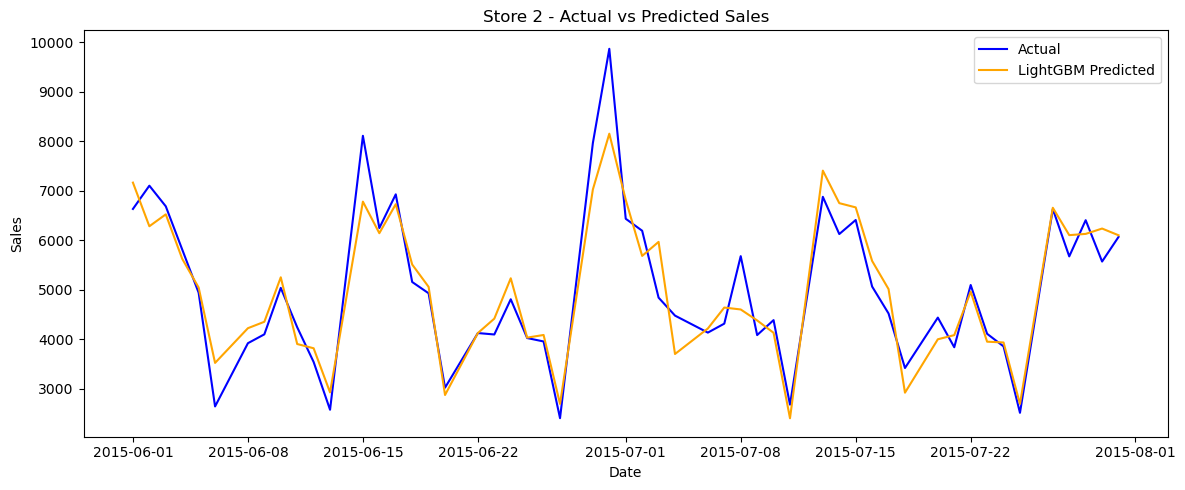

LightGBM Results - Store 2:
MAE:  399.84
RMSE: 528.45
MAPE: 8.03%


In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error

train = pd.read_csv('train.csv', low_memory=False)
store = pd.read_csv('store.csv')

df = pd.merge(train, store, on='Store', how='left')
df['Date'] = pd.to_datetime(df['Date'])
df = df[(df['Open'] == 1) & (df['Sales'] > 0)]
selected_stores = [2, 3, 20, 30]
df = df[df['Store'].isin(selected_stores)]
df = df.sort_values(['Store', 'Date'])
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['WeekOfYear'] = df['Date'].dt.isocalendar().week.astype(int)
df['IsWeekend'] = df['DayOfWeek'].isin([6, 7]).astype(int)
df['Lag_7'] = df.groupby('Store')['Sales'].shift(7)
df['Lag_14'] = df.groupby('Store')['Sales'].shift(14)
df['Rolling_Mean_7'] = df.groupby('Store')['Sales'].transform(lambda x: x.shift(1).rolling(7).mean())
df['Rolling_Mean_14'] = df.groupby('Store')['Sales'].transform(lambda x: x.shift(1).rolling(14).mean())
df = df.dropna()

cutoff_date = '2015-06-01'
train_df = df[df['Date'] < cutoff_date]
test_df = df[df['Date'] >= cutoff_date]

store2_train_lgb = train_df[train_df['Store'] == 2]
store2_test_lgb = test_df[test_df['Store'] == 2].sort_values('Date')

features = ['Year', 'Month', 'Day', 'WeekOfYear', 'IsWeekend',
            'DayOfWeek', 'Promo', 'SchoolHoliday',
            'Lag_7', 'Lag_14', 'Rolling_Mean_7', 'Rolling_Mean_14']

X_train = store2_train_lgb[features]
y_train = store2_train_lgb['Sales']
X_test = store2_test_lgb[features]
y_test = store2_test_lgb['Sales']

lgb_model = lgb.LGBMRegressor(n_estimators=500, learning_rate=0.05, random_state=42)
lgb_model.fit(X_train, y_train)
lgb_pred = lgb_model.predict(X_test)

plt.figure(figsize=(12, 5))
plt.plot(store2_test_lgb['Date'].values, y_test.values, label='Actual', color='blue')
plt.plot(store2_test_lgb['Date'].values, lgb_pred, label='LightGBM Predicted', color='orange')
plt.title('Store 2 - Actual vs Predicted Sales')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.tight_layout()
plt.savefig('actual_vs_predicted.png')
plt.show()

mae = mean_absolute_error(y_test, lgb_pred)
rmse = np.sqrt(mean_squared_error(y_test, lgb_pred))
mape = np.mean(np.abs((y_test.values - lgb_pred) / y_test.values)) * 100
print("LightGBM Results - Store 2:")
print(f"MAE:  {round(mae, 2)}")
print(f"RMSE: {round(rmse, 2)}")
print(f"MAPE: {round(mape, 2)}%")

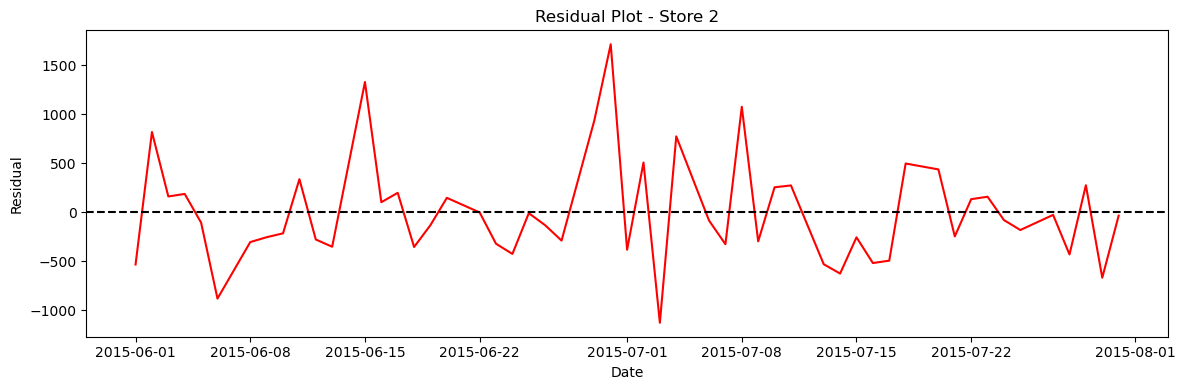

In [42]:
residuals = y_test.values - lgb_pred

plt.figure(figsize=(12, 4))
plt.plot(store2_test_lgb['Date'].values, residuals, color='red')
plt.axhline(y=0, color='black', linestyle='--')
plt.title('Residual Plot - Store 2')
plt.xlabel('Date')
plt.ylabel('Residual')
plt.tight_layout()
plt.savefig('residual_plot.png')
plt.show()

In [43]:
summary = {
    'Model': ['Prophet', 'LightGBM'],
    'MAE': [1438.71, 399.84],
    'RMSE': [1814.58, 528.45],
    'MAPE': ['32.26%', '8.03%']
}

summary_df = pd.DataFrame(summary)
print("Model Comparison - Store 2:")
print(summary_df.to_string(index=False))

print("\nConclusion:")
print("LightGBM is significantly better than Prophet.")
print("MAPE of 8.03% means predictions are within 8% of actual sales on average.")
print("Store 2 is relatively easy to predict due to consistent weekly patterns.")

Model Comparison - Store 2:
   Model     MAE    RMSE   MAPE
 Prophet 1438.71 1814.58 32.26%
LightGBM  399.84  528.45  8.03%

Conclusion:
LightGBM is significantly better than Prophet.
MAPE of 8.03% means predictions are within 8% of actual sales on average.
Store 2 is relatively easy to predict due to consistent weekly patterns.


In [45]:
lines = [
    "Sales Demand Forecasting - Rossmann Store Sales\n",
    "\nObjective\n",
    "Forecast future retail sales using time series and machine learning on Rossmann Store Sales dataset.\n",
    "\nDataset\n",
    "- Source: Kaggle - Rossmann Store Sales Competition\n",
    "- Size: 1,017,209 rows, 9 features\n",
    "- Stores used: 2, 3, 20, 30\n",
    "- Date range: 2013-01-02 to 2015-07-31\n",
    "\nFeature Engineering\n",
    "- Year, Month, Day, WeekOfYear extracted from Date\n",
    "- IsWeekend flag created from DayOfWeek\n",
    "- Lag_7, Lag_14: sales 7 and 14 days ago\n",
    "- Rolling_Mean_7, Rolling_Mean_14: rolling average sales\n",
    "- Time-based train/test split used - no random shuffle\n",
    "\nModels\n",
    "- Prophet (classical time series model)\n",
    "- LightGBM (tree-based model with lag features)\n",
    "\nResults - Store 2\n",
    "Model      | MAE     | RMSE    | MAPE\n",
    "Prophet    | 1438.71 | 1814.58 | 32.26%\n",
    "LightGBM   | 399.84  | 528.45  | 8.03%\n",
    "\nKey Findings\n",
    "- LightGBM outperforms Prophet significantly\n",
    "- Lag features and rolling means are most important predictors\n",
    "- Weekly seasonality is strong across all stores\n",
    "- Store 2 is easiest to predict due to consistent patterns\n",
    "\nHow to Run\n",
    "1. Clone the repository\n",
    "2. Install dependencies: pip install -r requirements.txt\n",
    "3. Place train.csv and store.csv in the project folder\n",
    "4. Open sales_forecasting.ipynb in Jupyter Notebook\n",
    "5. Run all cells in order\n",
]

with open('README.md', 'w') as f:
    f.writelines(lines)

requirements = "pandas==2.3.3\nnumpy==2.3.5\nmatplotlib==3.10.3\nseaborn==0.13.2\nscikit-learn==1.7.2\nlightgbm==4.6.0\nprophet==1.1.6\nstatsmodels==0.14.4\n"

with open('requirements.txt', 'w') as f:
    f.write(requirements)

print("README.md and requirements.txt created!")

README.md and requirements.txt created!
